#### **Import libraries and setup**

In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


#### **Exploratory Data Analysis (EDA)**

In [12]:
def count_images(folder):
    return len(os.listdir(folder))

train_chicken = "data/chicken-images/data/train"
train_duck = "data/duck-images/data/train"

print("Chicken Images:", count_images(train_chicken))
print("Duck Images:", count_images(train_duck))

Chicken Images: 275
Duck Images: 622


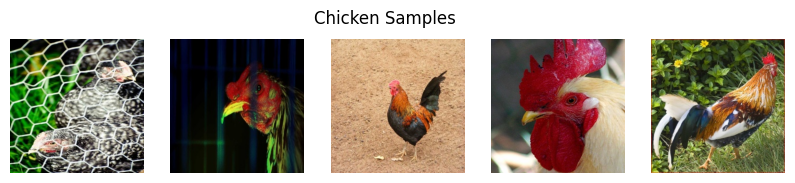

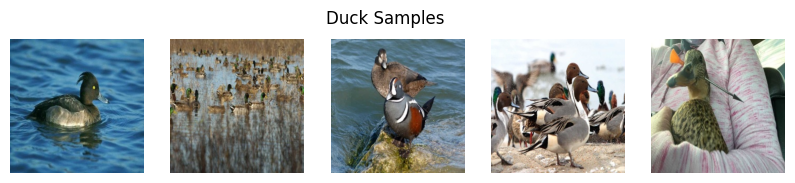

In [13]:
def show_samples(folder, title):
    images = os.listdir(folder)[:5]
    
    plt.figure(figsize=(10, 2))
    for i, img_name in enumerate(images):
        img = Image.open(os.path.join(folder, img_name))
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples(train_chicken, "Chicken Samples")
show_samples(train_duck, "Duck Samples")

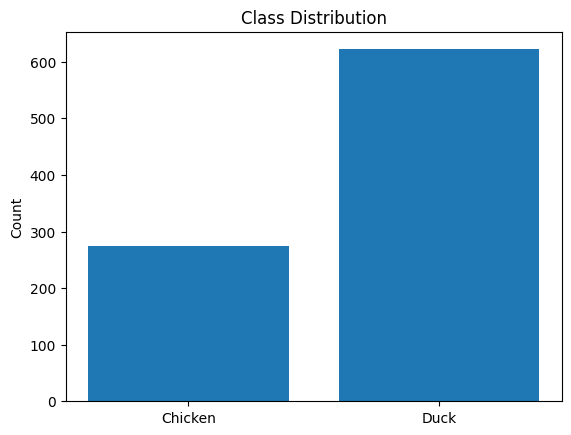

In [14]:
labels = ["Chicken", "Duck"]
counts = [count_images(train_chicken), count_images(train_duck)]

plt.figure()
plt.bar(labels, counts)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.show()

#### **Dataset Class**

In [15]:
class ChickenDuckDataset(Dataset):
    def __init__(self, chicken_dir, duck_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        for img in os.listdir(chicken_dir):
            self.image_paths.append(os.path.join(chicken_dir, img))
            self.labels.append(0)

        for img in os.listdir(duck_dir):
            self.image_paths.append(os.path.join(duck_dir, img))
            self.labels.append(1)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

#### **transforms the dataset**

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

#### **Dataset and Loaders**

In [17]:
train_dataset = ChickenDuckDataset(
    "data/chicken-images/data/train",
    "data/duck-images/data/train",
    transform=train_transform
)

val_dataset = ChickenDuckDataset(
    "data/chicken-images/data/val",
    "data/duck-images/data/val",
    transform=val_test_transform
)

test_dataset = ChickenDuckDataset(
    "data/chicken-images/data/test",
    "data/duck-images/data/test",
    transform=val_test_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

#### **Model(transfer Learning)**

In [18]:
model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

c:\Users\Arnab Bera\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Arnab Bera\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


#### **Loass and Optimizer**

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

In [20]:
def train_model(model, train_loader, val_loader, optimizer, epochs=5):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}, Val Acc {val_acc:.2f}%")

    return history

#### **Train (Before Fine-Tuning)**

In [21]:
history_before = train_model(model, train_loader, val_loader, optimizer, epochs=5)

Epoch 1: Train Loss 0.5333, Val Acc 85.09%
Epoch 2: Train Loss 0.2756, Val Acc 86.34%
Epoch 3: Train Loss 0.2079, Val Acc 86.34%
Epoch 4: Train Loss 0.2483, Val Acc 90.06%
Epoch 5: Train Loss 0.2046, Val Acc 89.44%


#### **Fine-Tuning**

In [22]:
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-4}
])

#### **Train (After Fine-Tuning)**

In [23]:
history_after = train_model(model, train_loader, val_loader, optimizer, epochs=5)

Epoch 1: Train Loss 0.1506, Val Acc 90.06%
Epoch 2: Train Loss 0.1285, Val Acc 88.20%
Epoch 3: Train Loss 0.1040, Val Acc 91.93%
Epoch 4: Train Loss 0.0789, Val Acc 88.82%
Epoch 5: Train Loss 0.0735, Val Acc 92.55%


#### **Plot Learning Curves**

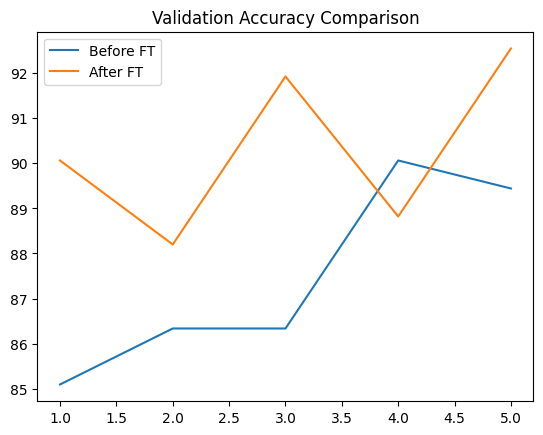

In [24]:
def plot_curves(h1, h2):
    epochs = range(1, len(h1["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, h1["val_acc"], label="Before FT")
    plt.plot(epochs, h2["val_acc"], label="After FT")
    plt.legend()
    plt.title("Validation Accuracy Comparison")
    plt.show()

plot_curves(history_before, history_after)

#### **Overfitting Detection**

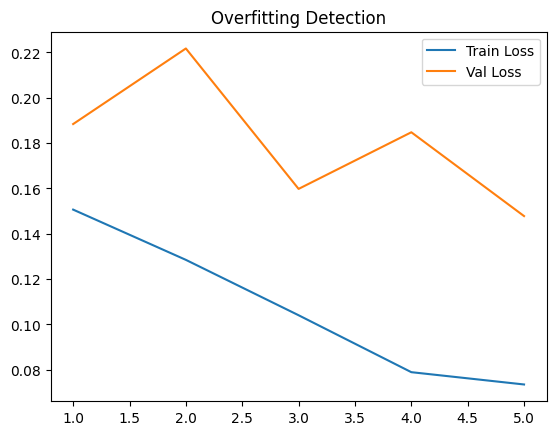

In [25]:
def plot_overfitting(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Overfitting Detection")
    plt.show()

plot_overfitting(history_after)

#### **Final Evaluation**

In [26]:
def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=["Chicken", "Duck"]))
    print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

evaluate_model(model, test_loader)

              precision    recall  f1-score   support

     Chicken       0.99      0.88      0.94       172
        Duck       0.94      1.00      0.97       310

    accuracy                           0.96       482
   macro avg       0.97      0.94      0.95       482
weighted avg       0.96      0.96      0.96       482

Confusion Matrix:
 [[152  20]
 [  1 309]]
